In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import os 
import time 
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

In [9]:
BASE_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [10]:
NUM_CLASSES = 38
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
INITIAL_EPOCHS = 10  
FINE_TUNE_EPOCHS = 5 
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS 

MODEL_ID = "DenseNet121" 
TRAIN_PORTION = 0.5

In [11]:
print("\nLoading Training Set...")
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path, 
    labels="inferred", 
    label_mode="int", 
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, 
    color_mode="rgb", 
    shuffle=True
)
total_batches = training_set.cardinality().numpy()

training_set = training_set.shuffle(buffer_size=100).take(int(total_batches * TRAIN_PORTION))
print(f"Training set loaded, using {int(total_batches * TRAIN_PORTION)} batches ({TRAIN_PORTION*100}%).")


validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=1,
    image_size=IMG_SIZE,
    shuffle=False, 
)
class_name = test_set.class_names


Loading Training Set...
Found 70295 files belonging to 38 classes.
Training set loaded, using 1098 batches (50.0%).
Found 17572 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [12]:
base_densenet = DenseNet121(
    weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,)
)
base_densenet.trainable = False

densenet_model = tf.keras.models.Sequential([
    base_densenet,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax") 
])

In [13]:
densenet_model.compile(
    optimizer=optimizers.Adam(1e-3), 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n--- DenseNet121 Model Summary (Feature Extraction) ---")
densenet_model.summary()


--- DenseNet121 Model Summary (Feature Extraction) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,309,670 (27.88 MB)

 Trainable params: 272,166 (1.04 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [14]:
print(f"\nStarting Phase 1 (Feature Extraction) for {INITIAL_EPOCHS} epochs...")
start_time = time.time() 
history_initial = densenet_model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=INITIAL_EPOCHS
)
print("Phase 1 finished.")


Starting Phase 1 (Feature Extraction) for 10 epochs...
Epoch 1/10


I0000 00:00:1765661257.971666     117 service.cc:148] XLA service 0x79d5e400b200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765661257.973199     117 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765661257.973221     117 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765661260.801118     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1098 ━━━━━━━━━━━━━━━━━━━━ 10:18:49 34s/step - accuracy: 0.0000e+00 - loss: 12.3652

I0000 00:00:1765661272.944129     117 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1098/1098 ━━━━━━━━━━━━━━━━━━━━ 169s 124ms/step - accuracy: 0.3646 - loss: 2.7149 - val_accuracy: 0.7590 - val_loss: 0.8058
Epoch 2/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.6827 - loss: 1.0428 - val_accuracy: 0.8234 - val_loss: 0.5825
Epoch 3/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.7394 - loss: 0.8458 - val_accuracy: 0.8302 - val_loss: 0.5428
Epoch 4/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.7572 - loss: 0.7709 - val_accuracy: 0.8480 - val_loss: 0.4726
Epoch 5/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.7752 - loss: 0.7150 - val_accuracy: 0.8652 - val_loss: 0.4162
Epoch 6/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.7878 - loss: 0.6719 - val_accuracy: 0.8408 - val_loss: 0.4853
Epoch 7/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.7951 - loss: 0.6406 - val_accuracy: 0.8761 - val_loss: 0.3872
Epoch 8/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 122s 109ms/step - accuracy: 0.8

In [15]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1
)
ft_callbacks = [early_stopping, lr_scheduler]

In [16]:
base_densenet.trainable = True

UNFREEZE_LAYERS_FROM = len(base_densenet.layers) - 40 
for layer in base_densenet.layers[:UNFREEZE_LAYERS_FROM]:
    layer.trainable = False 

densenet_model.compile(
    optimizer=optimizers.Adam(1e-5), 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
print(f"\nStarting Phase 2 (Fine-Tuning) for max {FINE_TUNE_EPOCHS} epochs with callbacks and LR 1e-5...")

# Phase 2
history_fine_tune = densenet_model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_initial.epoch[-1] + 1,
    callbacks=ft_callbacks
)

end_time = time.time() 
training_time = end_time - start_time
print(f"Training finished. Total time: {training_time:.2f} seconds.")


Starting Phase 2 (Fine-Tuning) for max 5 epochs with callbacks and LR 1e-5...
Epoch 11/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 173s 128ms/step - accuracy: 0.2485 - loss: 4.6047 - val_accuracy: 0.6989 - val_loss: 1.0189 - learning_rate: 1.0000e-05
Epoch 12/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 128s 115ms/step - accuracy: 0.5886 - loss: 1.4094 - val_accuracy: 0.8277 - val_loss: 0.5793 - learning_rate: 1.0000e-05
Epoch 13/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 128s 115ms/step - accuracy: 0.6962 - loss: 0.9715 - val_accuracy: 0.8593 - val_loss: 0.4610 - learning_rate: 1.0000e-05
Epoch 14/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 128s 114ms/step - accuracy: 0.7454 - loss: 0.8084 - val_accuracy: 0.8769 - val_loss: 0.3962 - learning_rate: 1.0000e-05
Epoch 15/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 128s 114ms/step - accuracy: 0.7717 - loss: 0.7136 - val_accuracy: 0.8871 - val_loss: 0.3590 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.
Training finished. Total time: 1951.10 seconds

In [18]:
MODEL_SAVE_PATH = f"{MODEL_ID.lower()}_plant_disease_model.h5" 
try:
    densenet_model.save(MODEL_SAVE_PATH)
    print(f"\n✅ Model successfully saved as: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"\nError saving model: {e}")


✅ Model successfully saved as: densenet121_plant_disease_model.h5


In [19]:
train_loss, train_acc = densenet_model.evaluate(training_set, verbose=0)
print(f'\nTraining accuracy: {train_acc:.4f}')

val_loss, val_acc = densenet_model.evaluate(validation_set, verbose=0)
print(f'Validation accuracy: {val_acc:.4f}')


Training accuracy: 0.9097
Validation accuracy: 0.8871


In [20]:
y_pred_probs = densenet_model.predict(test_set, verbose=0) 
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = true_categories.numpy()
predicted_categories = tf.argmax(y_pred_probs, axis=1).numpy()

report = classification_report(Y_true, predicted_categories, target_names=class_name, output_dict=True)

print("\n--- Classification Report ---")
print(classification_report(Y_true, predicted_categories, target_names=class_name, digits=4))


--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9562    0.6925    0.8032       504
                                 Apple___Black_rot     0.8178    0.8853    0.8502       497
                          Apple___Cedar_apple_rust     0.8750    0.8909    0.8829       440
                                   Apple___healthy     0.8500    0.9143    0.8810       502
                               Blueberry___healthy     0.8393    0.9317    0.8831       454
          Cherry_(including_sour)___Powdery_mildew     0.9197    0.9525    0.9358       421
                 Cherry_(including_sour)___healthy     0.8876    0.9693    0.9266       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9225    0.8415    0.8801       410
                       Corn_(maize)___Common_rust_     0.9814    0.9958    0.9886       477
               Corn_(maize)___Northern_Leaf_Blig

In [21]:
history = {
    'accuracy': history_initial.history['accuracy'] + history_fine_tune.history['accuracy'],
    'val_accuracy': history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy'],
    'loss': history_initial.history['loss'] + history_fine_tune.history['loss'],
    'val_loss': history_initial.history['val_loss'] + history_fine_tune.history['val_loss'],
}

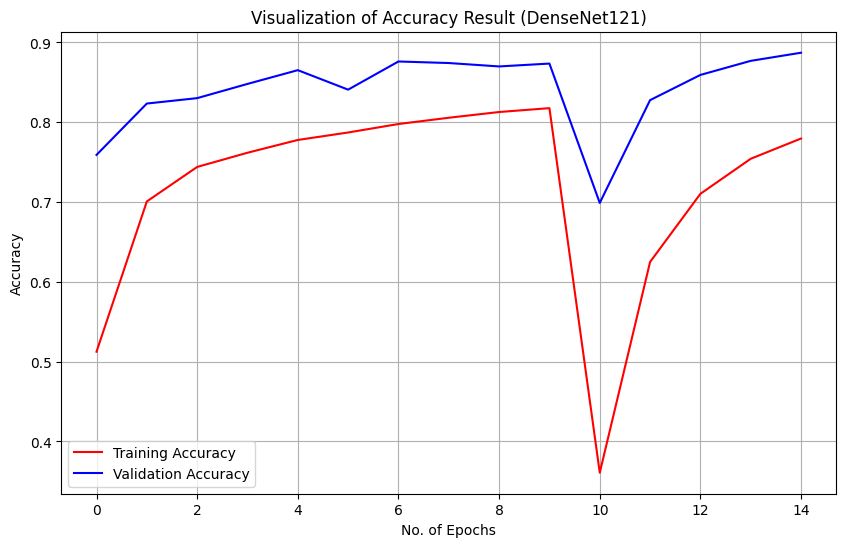

In [22]:
epochs_range = range(len(history['accuracy']))
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title(f'Visualization of Accuracy Result ({MODEL_ID})')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
metrics_summary = {
    'Model': MODEL_ID, 
    'Accuracy': report['accuracy'],
    'Precision (Wgt Avg)': report['weighted avg']['precision'], 
    'Recall (Wgt Avg)': report['weighted avg']['recall'],
    'F1-Score (Wgt Avg)': report['weighted avg']['f1-score'],
    'Training Time (s)': training_time, 
}

In [24]:
df_metrics = pd.DataFrame([metrics_summary])
results_file = 'model_performance_summary.csv'

if not os.path.exists(results_file):
    df_metrics.to_csv(results_file, index=False)
else:
    df_metrics.to_csv(results_file, mode='a', header=False, index=False)
    
print(f"\n✅ Metrics successfully saved/appended to {results_file}")


✅ Metrics successfully saved/appended to model_performance_summary.csv
